Hi Bingbong, please put your EDA here and save all the figures you will make into the `figures` folder.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path, engine='python', on_bad_lines='skip')
df["nutrition"] = df["nutrition"].apply(json.loads)

In [4]:
# Get the nutritional values
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_nutritions = df["nutrition"].apply(pd.Series)
df_nutritions.columns = nutrition_cols
df_nutritions.head()

,calories,total_fat_PDV,sugar_PDV,sodium_PDV,protein_PDV,saturated_fat_PDV,carbohydrates_PDV
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0


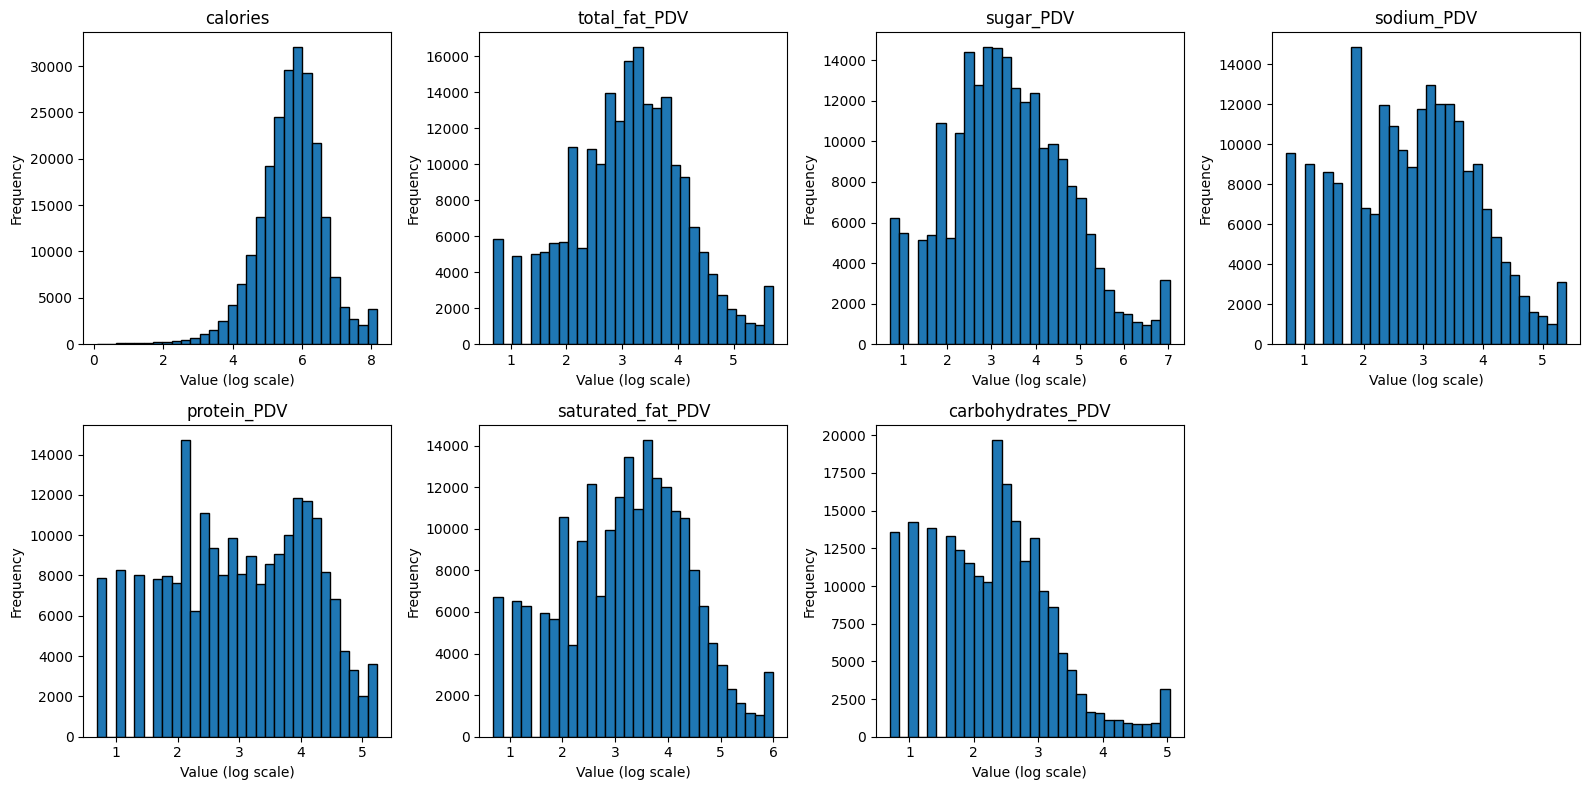

✅ Saved figure to: figures/nutrition_histograms_log.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ✅ Create folder if not exists
os.makedirs("figures", exist_ok=True)

# Copy dataframe
df_plot = df_nutritions.copy()

# Cap outliers at the 99th percentile per column
for col in df_plot.columns:
    upper = np.percentile(df_plot[col].dropna(), 99)
    df_plot[col] = np.clip(df_plot[col], 0, upper)

# Cutoff values
cutoffs = {
    "calories": 700,
    "carbohydrates_PDV": 40,
    "protein_PDV": 20,
    "saturated_fat_PDV": 35,
    "sodium_PDV": 35,
    "sugar_PDV": 30,
    "total_fat_PDV": 30
}

# Plot histograms with log-scaled x-axis
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_plot.columns):
    data = df_plot[col].dropna()
    data = data[data > 0]  # avoid zeros for log scale

    axes[i].hist(np.log1p(data), bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value (log scale)")
    axes[i].set_ylabel("Frequency")
    #axes[i].set_xscale("log")

    # # Add cutoff line & label
    # if col in cutoffs:
    #     cutoff = cutoffs[col]
    #     cutoff_transformed = np.log1p(cutoff).round(2)
    #     axes[i].axvline(cutoff_transformed, color='red', linestyle='--', linewidth=2)
    #     ymax = axes[i].get_ylim()[1]
    #     xmax = axes[i].get_xlim()[1]
    #     axes[i].text(
    #         cutoff_transformed - 0.2, ymax * 0.95,
    #         f"Cutoff:\n{cutoff_transformed}",
    #         color='red', fontsize=9, fontweight='bold',
    #         ha='right', va='top'
    #     )

# Remove empty subplot cell
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# ✅ Save figure into /figures folder
file_path = "figures/nutrition_histograms_log.png"
plt.savefig(file_path, dpi=300)

plt.show()

print(f"✅ Saved figure to: {file_path}")

array([[<Axes: title={'center': 'calories'}>,
        <Axes: title={'center': 'total_fat_PDV'}>,
        <Axes: title={'center': 'sugar_PDV'}>],
       [<Axes: title={'center': 'sodium_PDV'}>,
        <Axes: title={'center': 'protein_PDV'}>,
        <Axes: title={'center': 'saturated_fat_PDV'}>],
       [<Axes: title={'center': 'carbohydrates_PDV'}>, <Axes: >,
        <Axes: >]], dtype=object)

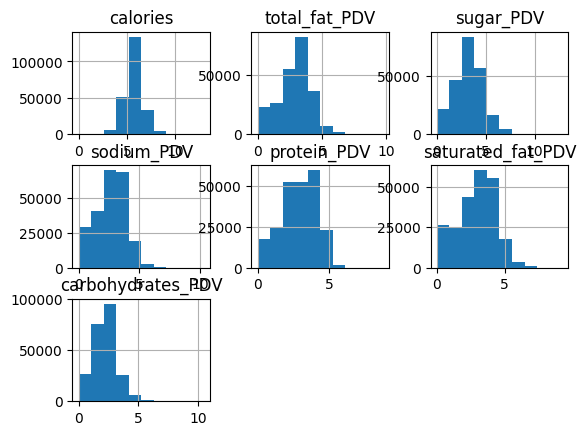

In [12]:
np.log1p(df_nutritions).hist()